<a href="https://colab.research.google.com/github/Frank497/NTHU_2023_DLBOI_HW/blob/main/IC_Week1_Pixel_Simulation_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. CMOS:
Light -> photodiode -> Current -> Capacitor -> Voltage
# 2. Core equation:\ V=I_photo*t/C
I_photo: light generated current\
t: exposure time\
C: pixel capacitance

Pixel Simulation of CMOS

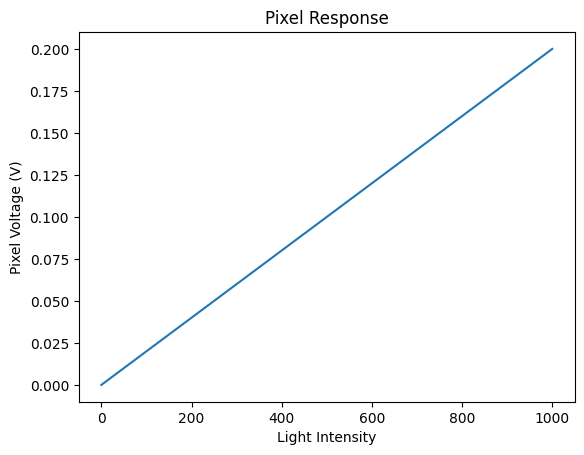

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# parameters
C = 5e-15  # capacitance (F)
t = 0.001   # integration time (s)
k = 1e-15   # conversion gain

light = np.linspace(0, 1000, 100)
I_photo = k * light

V_out = (I_photo * t) / C

plt.plot(light, V_out)
plt.xlabel("Light Intensity")
plt.ylabel("Pixel Voltage (V)")
plt.title("Pixel Response")
plt.show()

Add Saturation (real pixel saturate at ~1V)

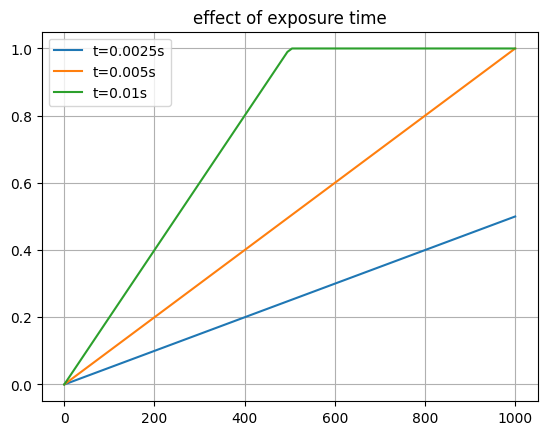

In [ ]:
#saturation voltage
V_sat = 1.0
#change exposure time
t_values = [0.0025, 0.005, 0.01]

plt.figure()
for t in t_values:
  V_out = (k*light*t)/C
  V_clipped = np.clip(V_out, 0, V_sat)
  plt.plot(light, V_clipped, label=f"t={t}s")
plt.legend()
plt.title("effect of exposure time")
plt.grid()
plt.show()


Load Image as Light Input with saturation and adjustable exposure

In [ ]:
import ipywidgets as widgets
import requests
from ipywidgets import interact
import cv2
#download and read image
url = f"https://drive.google.com/uc?id=1iwFfPewCXvAbxdZYo0cKMkTxoVqNshSW"
response = requests.get(url)
img_array = np.asarray(bytearray(response.content), dtype=np.uint8)
img = cv2.imdecode(img_array, 0)
img = cv2.resize(img, (128, 128))
light_img = img.astype(float)

#turn into light input
def update(t):
    V_img = (k * light_img * t) / C /1000
    #t in ms
    V_img = np.clip(V_img, 0, 1.0)

    plt.imshow(V_img, cmap='gray', vmin=0, vmax=1)
    plt.title(f"Simulated Sensor Output (t={t:.4f} ms)")
    plt.axis('off')
    plt.show()

interact(update, t=widgets.FloatSlider(min=0.0, max=50, step=1, value=25))

interactive(children=(FloatSlider(value=25.0, description='t', max=50.0, step=1.0), Output()), _dom_classes=('…

<function __main__.update(t)>